In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Loading  dataset
data = pd.read_csv("multiple_linear_regression_dataset.csv")
print("First 5 rows:")
print(data.head())

print("\nCol names:", data.columns.tolist())
print("\nshape:", data.shape)
print("\nbasic stats:")
print(data.describe())

First 5 rows:
   age  experience  income
0   25           1   30450
1   30           3   35670
2   47           2   31580
3   32           5   40130
4   43          10   47830

Col names: ['age', 'experience', 'income']

shape: (20, 3)

basic stats:
             age  experience        income
count  20.000000   20.000000     20.000000
mean   39.650000    6.200000  40735.500000
std    10.027725    4.124382   8439.797625
min    23.000000    1.000000  27840.000000
25%    31.500000    3.750000  35452.500000
50%    40.000000    5.000000  40190.000000
75%    47.000000    9.000000  45390.000000
max    58.000000   17.000000  63600.000000


- Inputs are: age, experience
- Output is: income
- Model needs to handle 2 features, so 2 weights needed

In [5]:
X = data[["age", "experience"]].values
y = data["income"].values

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

# X has 2 columns because we have 2 input features
# y has 1 column because we predict only one thing - salary

Shape of X: (20, 2)
Shape of y: (20,)


In [6]:
n_features = X.shape[1]

w = np.zeros(n_features)

# bias also starts at zero
b = 0.0

print("Initial weights:", w)
print("Initial bias:", b)

# one weight per feature because each feature contributes differently
# bias is separate - it shifts prediction without depending on input
# large initial values would cause gradients to explode during training

Initial weights: [0. 0.]
Initial bias: 0.0


In [7]:
def predict(X, w, b):
    y_hat = X.dot(w) + b
    return y_hat

y_test = predict(X, w, b)
print("Test predictions (first 5):", y_test[:5])

# no activation because salary is a number, not a class
# y_hat can be any real number - that's what we want
# unlike logistic regression which squashes output to 0-1

#loss function
def mean_squared_error(y, y_hat):
    loss = ((y_hat - y) ** 2).mean()
    return loss
initial_loss = mean_squared_error(y, y_test)
print(f"Loss before training: {initial_loss:.2f}")

# squaring because: makes errors positive, penalizes large errors more
# if one prediction is very wrong, squared error pulls weights hard to fix it
# absolute error not used because it's not differentiable at zero

Test predictions (first 5): [0. 0. 0. 0. 0.]
Loss before training: 1727049635.00


In [8]:
def compute_gradients(X, y, y_hat):
    N = len(y)

    error = y_hat - y
    dw = (2 / N) * X.T.dot(error)
    db = (2 / N) * error.sum()

    return dw, db

def update_parameters(w, b, dw, db, lr):
    w = w - lr * dw
    b = b - lr * db
    return w, b

# lr too large = weights overshoot, loss explodes
# lr too small = training takes forever

In [9]:
w = np.zeros(n_features)
b = 0.0
lr = 0.0001
epochs = 1000

loss_history = []

for epoch in range(epochs):
    y_hat = predict(X, w, b)

    loss = mean_squared_error(y, y_hat)
    loss_history.append(loss)

    dw, db = compute_gradients(X, y, y_hat)

    w, b = update_parameters(w, b, dw, db, lr)

    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d}  |  Loss: {loss:.4f}")

print(f"\nFinal loss after {epochs} epochs: {loss_history[-1]:.4f}")

Epoch    0  |  Loss: 1727049635.0000
Epoch  100  |  Loss: 66491868.5531
Epoch  200  |  Loss: 61752567.2012
Epoch  300  |  Loss: 58616531.0785
Epoch  400  |  Loss: 56528801.5395
Epoch  500  |  Loss: 55126542.0295
Epoch  600  |  Loss: 54172526.9489
Epoch  700  |  Loss: 53511656.1429
Epoch  800  |  Loss: 53042523.7280
Epoch  900  |  Loss: 52698829.5633

Final loss after 1000 epochs: 52439538.1831


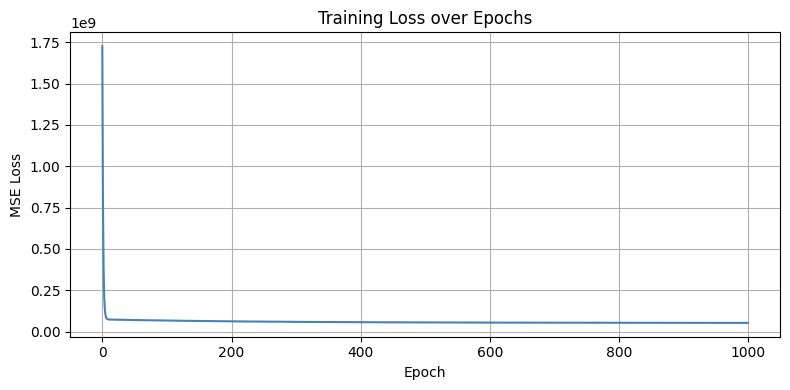

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='steelblue')
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
print("final weights:")
print(f"  w1 (age) = {w[0]:.4f}")
print(f"  w2 (experience)       = {w[1]:.4f}")
print(f"  Bias (b)             = {b:.4f}")

new_candidate = np.array([28, 4.5])
predicted_income = new_candidate.dot(w) + b
print(f"Predicted income: {predicted_income:.2f}")

y_final = predict(X, w, b)
print("\nActual vs Predicted (first 5 samples):")
for i in range(5):
    print(f"  Actual: {y[i]:.0f}  |  Predicted: {y_final[i]:.0f}  |  Error: {abs(y[i]-y_final[i]):.0f}")

# prediction is reasonable because it falls within dataset salary range
# interpolates smoothly because model is linear - no sudden jumps
# better than threshold rules because it combines both features continuously

final weights:
  w1 (age) = 764.7541
  w2 (experience)       = 1371.0343
  Bias (b)             = 321.7364
Predicted income: 27904.50

Actual vs Predicted (first 5 samples):
  Actual: 30450  |  Predicted: 20812  |  Error: 9638
  Actual: 35670  |  Predicted: 27377  |  Error: 8293
  Actual: 31580  |  Predicted: 39007  |  Error: 7427
  Actual: 40130  |  Predicted: 31649  |  Error: 8481
  Actual: 47830  |  Predicted: 46917  |  Error: 913
